In [18]:
import numpy as np
import pandas as pd

In [19]:
df = pd.read_csv(r'placement.csv')

In [20]:
df.head()

,cgpa,iq,internship,projects,dsa_rating,placement
0,6.8,123.0,1,2,2195,1
1,5.9,106.0,0,0,841,0
2,5.3,121.0,0,2,1007,0
3,7.4,132.0,1,6,1976,1
4,5.8,142.0,1,0,949,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cgpa        500 non-null    float64
 1   iq          500 non-null    float64
 2   internship  500 non-null    int64  
 3   projects    500 non-null    int64  
 4   dsa_rating  500 non-null    int64  
 5   placement   500 non-null    int64  
dtypes: float64(2), int64(4)
memory usage: 23.6 KB


In [6]:
df.shape

(500, 6)

In [ ]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns


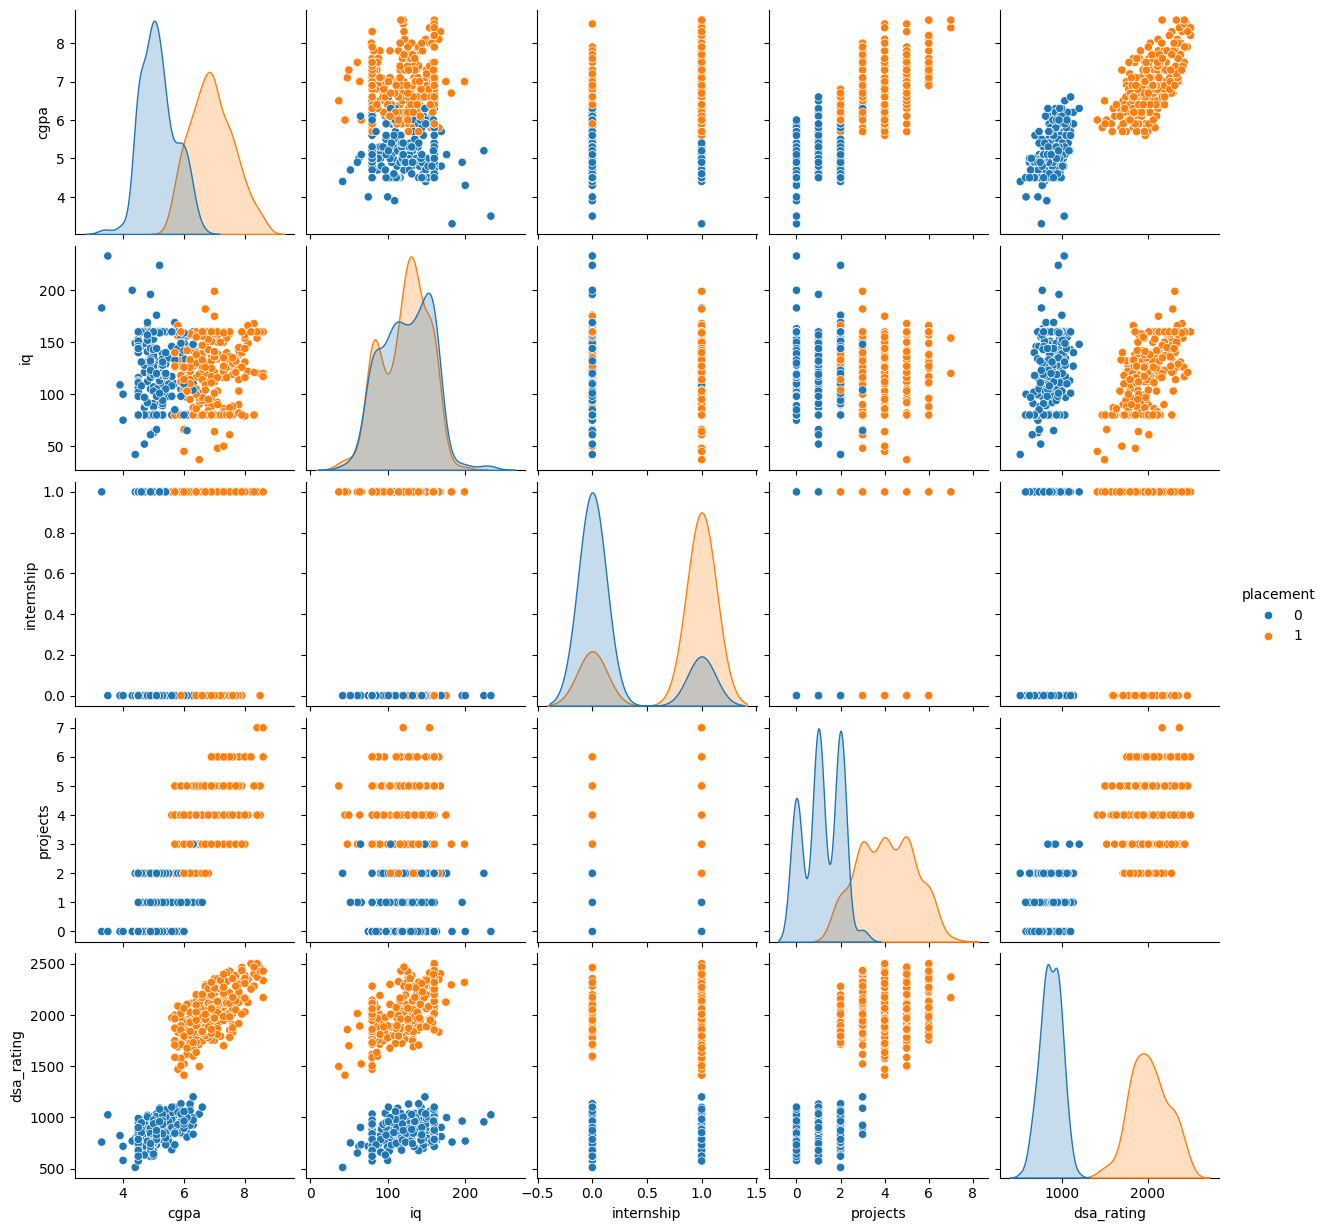

In [26]:
sns.pairplot(
    df,
    hue='placement'
)

plt.show()

In [34]:
X = df.iloc[:,0:4]
y = df.iloc[:,-1]


In [35]:
X

,cgpa,iq,internship,projects
0,6.8,123.0,1,2
1,5.9,106.0,0,0
2,5.3,121.0,0,2
3,7.4,132.0,1,6
4,5.8,142.0,1,0
...,...,...,...,...
495,4.5,160.0,0,2
496,4.5,80.0,0,2
497,6.9,160.0,0,5
498,6.1,103.0,1,5


In [36]:
y.shape

(500,)

In [40]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [41]:
X_train

,cgpa,iq,internship,projects
443,6.1,142.0,1,5
70,6.3,127.0,1,2
412,5.3,131.0,0,0
104,6.2,127.0,0,1
316,5.1,160.0,0,1
...,...,...,...,...
370,6.4,130.0,1,2
33,6.0,149.0,0,0
486,4.9,132.0,0,1
140,4.8,131.0,0,2


In [42]:
y_train

443    1
70     1
412    0
104    0
316    0
      ..
370    1
33     0
486    0
140    0
442    1
Name: placement, Length: 400, dtype: int64

In [43]:
X_test

,cgpa,iq,internship,projects
132,7.4,140.0,1,5
84,5.7,169.0,0,2
373,4.5,80.0,0,1
317,4.5,160.0,0,1
258,7.5,80.0,1,3
...,...,...,...,...
388,4.5,151.0,0,2
277,7.6,80.0,1,6
314,6.6,101.0,0,1
157,6.5,139.0,1,2


In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()

In [46]:
X_train = scaler.fit_transform(X_train)

In [47]:
X_train

array([[ 0.09235643,  0.59694017,  1.05131497,  1.33541063],
       [ 0.27569424,  0.10677444,  1.05131497, -0.32692625],
       [-0.64099484,  0.2374853 , -0.95118973, -1.43515085],
       ...,
       [-1.00767048,  0.27016301, -0.95118973, -0.88103855],
       [-1.09933938,  0.2374853 , -0.95118973, -0.32692625],
       [ 1.37572114, -1.42907819,  1.05131497,  0.22718604]],
      shape=(400, 4))

In [48]:
X_test = scaler.transform(X_test)

In [49]:
X_test

array([[ 1.28405224e+00,  5.31584737e-01,  1.05131497e+00,
         1.33541063e+00],
       [-2.74319209e-01,  1.47923849e+00, -9.51189731e-01,
        -3.26926255e-01],
       [-1.37434611e+00, -1.42907819e+00, -9.51189731e-01,
        -8.81038552e-01],
       [-1.37434611e+00,  1.18513905e+00, -9.51189731e-01,
        -8.81038552e-01],
       [ 1.37572114e+00, -1.42907819e+00,  1.05131497e+00,
         2.27186042e-01],
       [-7.32663751e-01, -1.10230104e+00,  1.05131497e+00,
        -3.26926255e-01],
       [-6.40994842e-01,  1.39452151e-01, -9.51189731e-01,
        -8.81038552e-01],
       [ 5.50700968e-01,  1.18513905e+00, -9.51189731e-01,
         2.27186042e-01],
       [ 1.84025334e-01,  1.11978362e+00,  1.05131497e+00,
         7.81298338e-01],
       [ 6.42369876e-01,  1.72129866e-01,  1.05131497e+00,
         7.81298338e-01],
       [-7.32663751e-01, -4.48746728e-01, -9.51189731e-01,
        -3.26926255e-01],
       [-4.57657026e-01,  3.35518444e-01, -9.51189731e-01,
      

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
clf = LogisticRegression()

In [52]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_pred = clf.predict(X_test)

In [57]:
y_test

132    1
84     0
373    0
317    0
258    1
      ..
388    0
277    1
314    0
157    1
247    0
Name: placement, Length: 100, dtype: int64

In [58]:
from sklearn.metrics import accuracy_score

In [59]:
accuracy_score(y_test,y_pred)

0.98

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [65]:
cm = confusion_matrix(y_test, y_pred)

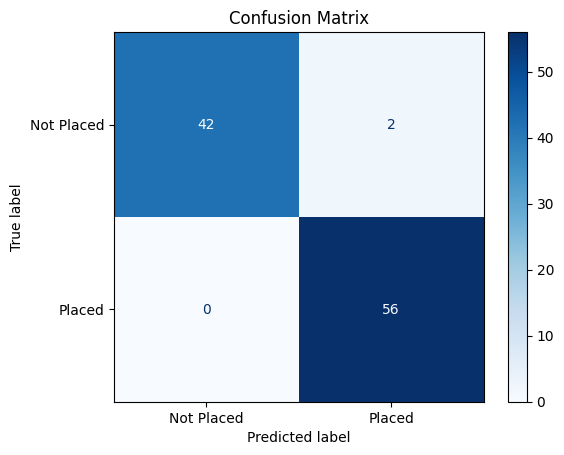

In [66]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [67]:
import pickle

In [68]:
pickle.dump(clf,open('model.pkl','wb'))

In [69]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)